# Módulo A.3 – Python para Machine Learning

**INSTITUTO SUPERIOR DE ENGENHARIA DE LISBOA**  
**Licenciatura em Engenharia Informática e de Computadores**  
**Fundamentos de Ciências de Dados — Verão 2025/2026**

---

## Configuração do ambiente

Bibliotecas utilizadas:
- **matplotlib** — visualização de dados
- **numpy** — computação científica
- **pandas** — manipulação de dados
- **scikit-learn** — aprendizagem automática
- **seaborn** — análise estatística e visualização

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('dados', exist_ok=True)

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


---

## 2. Visualização de dados e conversão entre formatos

### 2(a) Análise de três conjuntos de dados

Os três conjuntos de dados escolhidos são:

| # | Conjunto de dados | Fonte |
|---|-------------------|---------|
| 1 | **Iris** | `sklearn.datasets.load_iris()` |
| 2 | **Penguins** | `seaborn.load_dataset('penguins')` |
| 3 | **Titanic** | `seaborn.load_dataset('titanic')` |

Para cada conjunto de dados são analisados:
- Número total de características
- Número de características numéricas
- Número de características categóricas
- Percentagem de valores omissos
- Tipo de problema (classificação ou regressão)

In [2]:
def analisar_dataset(nome, df_features, problema):
    """Analisa e apresenta as características de um conjunto de dados."""
    numericas = df_features.select_dtypes(include=[np.number]).shape[1]
    categoricas = df_features.select_dtypes(include=['object', 'category', 'bool']).shape[1]
    total = df_features.shape[1]
    total_valores = df_features.shape[0] * df_features.shape[1]
    omissos = df_features.isnull().sum().sum() / total_valores * 100

    print(f'\n{'='*50}')
    print(f'  Conjunto de dados: {nome}')
    print(f'{'='*50}')
    print(f'  (i)   Número total de características : {total}')
    print(f'  (ii)  Características numéricas       : {numericas}')
    print(f'  (iii) Características categóricas     : {categoricas}')
    print(f'  (iv)  Percentagem de valores omissos  : {omissos:.2f}%')
    print(f'  (v)   Problema associado              : {problema}')
    return {
        'total': total, 'numericas': numericas,
        'categoricas': categoricas, 'omissos_pct': omissos,
        'problema': problema
    }

#### Dataset 1 — Iris

O conjunto de dados **Iris** contém medidas de sépalas e pétalas de três espécies de flores iris (*setosa*, *versicolor* e *virginica*). É um dos conjuntos de dados mais utilizados em aprendizagem automática para tarefas de classificação multiclasse.

- **Instâncias**: 150 (50 por classe)
- **Formato original**: CSV (disponível em [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/iris))
- **Formato convertido**: JSON

In [3]:
# Carregar dataset Iris
iris_raw = load_iris(as_frame=True)
df_iris = iris_raw.data.copy()
df_iris['target'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

analisar_dataset('Iris', iris_raw.data, 'Classificação (multiclasse: 3 classes)')

print('\nPrimeiras 5 linhas do Iris:')
display(df_iris.head())

# Converter para JSON
df_iris.to_csv('dados/iris.csv', index=False)
df_iris.to_json('dados/iris.json', orient='records', indent=2)
print('\nIris guardado em dados/iris.csv e dados/iris.json')


  Conjunto de dados: Iris
  (i)   Número total de características : 4
  (ii)  Características numéricas       : 4
  (iii) Características categóricas     : 0
  (iv)  Percentagem de valores omissos  : 0.00%
  (v)   Problema associado              : Classificação (multiclasse: 3 classes)

Primeiras 5 linhas do Iris:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Iris guardado em dados/iris.csv e dados/iris.json


#### Dataset 2 — Penguins

O conjunto de dados **Penguins** contém medidas morfológicas de três espécies de pinguins (*Adelie*, *Chinstrap* e *Gentoo*), recolhidas no arquipélago Palmer, na Antártida. É uma alternativa moderna ao Iris, incluindo características numéricas e categóricas e apresentando valores omissos.

- **Instâncias**: 344
- **Formato original**: CSV (disponível em [palmerpenguins](https://github.com/allisonhorst/palmerpenguins))
- **Formato convertido**: JSON

In [4]:
# Carregar dataset Penguins
df_penguins = sns.load_dataset('penguins')
features_penguins = df_penguins.drop(columns=['species'])

analisar_dataset('Penguins', features_penguins, 'Classificação (multiclasse: 3 classes)')

print('\nPrimeiras 5 linhas do Penguins:')
display(df_penguins.head())

print('\nValores omissos por coluna:')
print(df_penguins.isnull().sum())

# Converter para JSON
df_penguins.to_csv('dados/penguins.csv', index=False)
df_penguins.to_json('dados/penguins.json', orient='records', indent=2)
print('\nPenguins guardado em dados/penguins.csv e dados/penguins.json')


  Conjunto de dados: Penguins
  (i)   Número total de características : 6
  (ii)  Características numéricas       : 4
  (iii) Características categóricas     : 2
  (iv)  Percentagem de valores omissos  : 0.92%
  (v)   Problema associado              : Classificação (multiclasse: 3 classes)

Primeiras 5 linhas do Penguins:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Valores omissos por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Penguins guardado em dados/penguins.csv e dados/penguins.json


#### Dataset 3 — Titanic

O conjunto de dados **Titanic** regista informação sobre os passageiros do naufrágio do RMS Titanic em 1912. O objetivo é prever se um passageiro sobreviveu ou não. Inclui características numéricas e categóricas, bem como uma percentagem considerável de valores omissos (principalmente na coluna *age*).

- **Instâncias**: 891
- **Formato original**: CSV (disponível em [Kaggle](https://www.kaggle.com/c/titanic))
- **Formato convertido**: JSON

In [5]:
# Carregar dataset Titanic (subconjunto de características relevantes)
df_titanic_full = sns.load_dataset('titanic')
df_titanic = df_titanic_full[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()
features_titanic = df_titanic.drop(columns=['survived'])

analisar_dataset('Titanic', features_titanic, 'Classificação (binária: sobreviveu / não sobreviveu)')

print('\nPrimeiras 5 linhas do Titanic:')
display(df_titanic.head())

print('\nValores omissos por coluna:')
print(df_titanic.isnull().sum())

# Converter para JSON
df_titanic.to_csv('dados/titanic.csv', index=False)
df_titanic.to_json('dados/titanic.json', orient='records', indent=2)
print('\nTitanic guardado em dados/titanic.csv e dados/titanic.json')


  Conjunto de dados: Titanic
  (i)   Número total de características : 5
  (ii)  Características numéricas       : 3
  (iii) Características categóricas     : 2
  (iv)  Percentagem de valores omissos  : 4.02%
  (v)   Problema associado              : Classificação (binária: sobreviveu / não sobreviveu)

Primeiras 5 linhas do Titanic:


,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S



Valores omissos por coluna:
survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64

Titanic guardado em dados/titanic.csv e dados/titanic.json


#### Resumo dos três conjuntos de dados

In [6]:
resumo = pd.DataFrame({
    'Dataset': ['Iris', 'Penguins', 'Titanic'],
    'Instâncias': [150, 344, 891],
    'Total de características': [4, 6, 5],
    'Numéricas': [4, 4, 3],
    'Categóricas': [0, 2, 2],
    'Valores omissos (%)': ['0.00%', '0.92%', '4.02%'],
    'Problema': ['Classificação', 'Classificação', 'Classificação']
})
display(resumo)

,Dataset,Instâncias,Total de características,Numéricas,Categóricas,Valores omissos (%),Problema
0,Iris,150,4,4,0,0.00%,Classificação
1,Penguins,344,6,4,2,0.92%,Classificação
2,Titanic,891,5,3,2,4.02%,Classificação


---

### 2(b) Visualização do conjunto de dados Iris

#### Scatter-plots entre três pares de variáveis

São apresentados scatter-plots entre os seguintes pares de variáveis do dataset Iris:
1. *Sepal length* vs *Sepal width*
2. *Petal length* vs *Petal width*
3. *Sepal length* vs *Petal length*

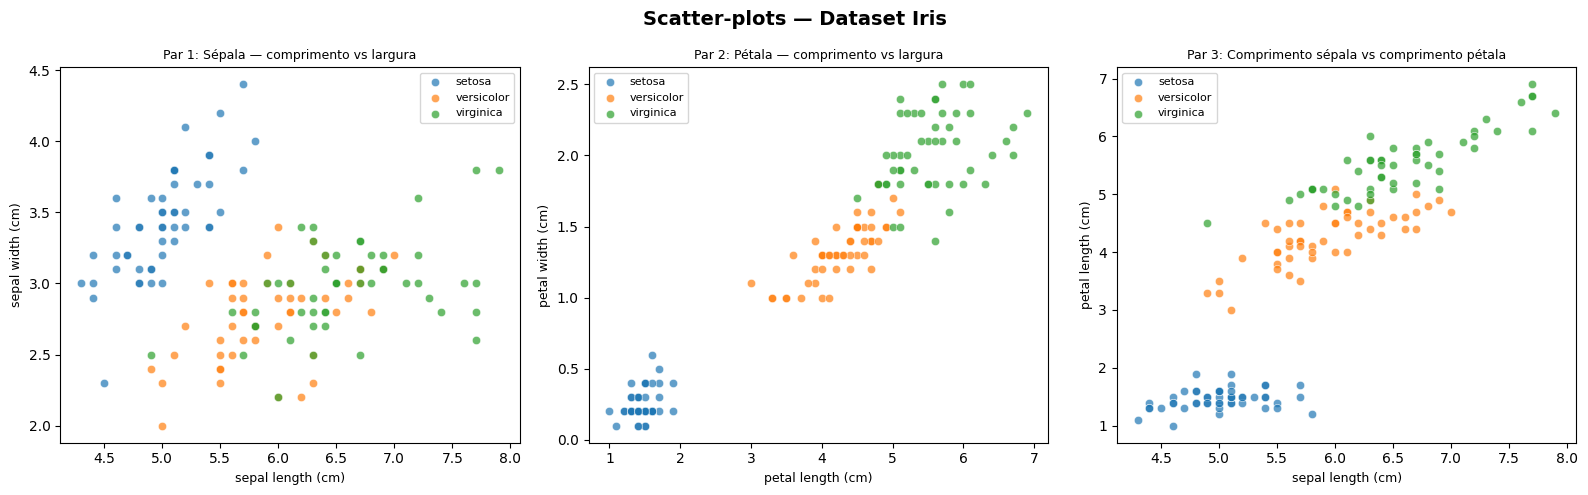

Figura guardada em dados/scatter_iris.png


In [7]:
iris_raw = load_iris(as_frame=True)
df_iris_plot = iris_raw.data.copy()
df_iris_plot['especie'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

pares = [
    ('sepal length (cm)', 'sepal width (cm)',  'Par 1: Sépala — comprimento vs largura'),
    ('petal length (cm)', 'petal width (cm)',  'Par 2: Pétala — comprimento vs largura'),
    ('sepal length (cm)', 'petal length (cm)', 'Par 3: Comprimento sépala vs comprimento pétala'),
]

palette = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scatter-plots — Dataset Iris', fontsize=14, fontweight='bold')

for ax, (x, y, titulo) in zip(axes, pares):
    for especie, cor in palette.items():
        subset = df_iris_plot[df_iris_plot['especie'] == especie]
        ax.scatter(subset[x], subset[y], c=cor, label=especie, alpha=0.7, edgecolors='w', linewidths=0.5)
    ax.set_xlabel(x, fontsize=9)
    ax.set_ylabel(y, fontsize=9)
    ax.set_title(titulo, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dados/scatter_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada em dados/scatter_iris.png')

**Análise dos scatter-plots:**

- **Par 1 — Comprimento vs largura da sépala**: As três espécies apresentam alguma sobreposição, especialmente *versicolor* e *virginica*. A correlação entre as variáveis é fraca (r ≈ −0.12), e a distinção entre espécies não é clara apenas com estas duas variáveis.

- **Par 2 — Comprimento vs largura da pétala**: Existe uma forte correlação positiva (r ≈ 0.96) entre estas variáveis. As três espécies estão claramente separadas: *setosa* tem pétalas muito pequenas, enquanto *versicolor* e *virginica* formam dois grupos distintos.

- **Par 3 — Comprimento da sépala vs comprimento da pétala**: Correlação positiva forte (r ≈ 0.87). A separação entre *setosa* e as restantes classes é evidente; *versicolor* e *virginica* apresentam alguma sobreposição.

#### Gráfico de barras — número de instâncias por classe

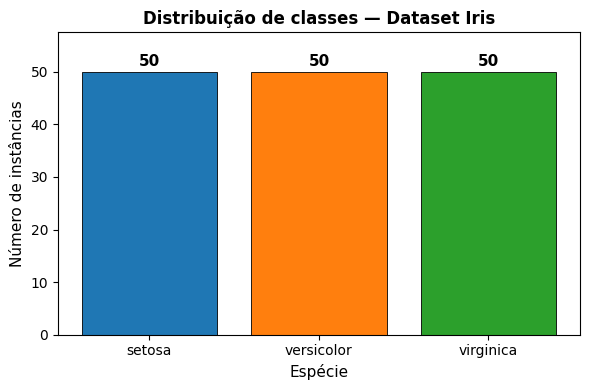

Figura guardada em dados/bar_chart_iris.png

Distribuição de classes:
especie
setosa        50
versicolor    50
virginica     50

O dataset Iris é perfeitamente balanceado (50 instâncias por classe).


In [8]:
contagens = df_iris_plot['especie'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(contagens.index, contagens.values,
              color=[palette[e] for e in contagens.index],
              edgecolor='black', linewidth=0.6)

for bar, val in zip(bars, contagens.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Espécie', fontsize=11)
ax.set_ylabel('Número de instâncias', fontsize=11)
ax.set_title('Distribuição de classes — Dataset Iris', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(contagens.values) * 1.15)

plt.tight_layout()
plt.savefig('dados/bar_chart_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada em dados/bar_chart_iris.png')
print(f'\nDistribuição de classes:\n{contagens.to_string()}')
print('\nO dataset Iris é perfeitamente balanceado (50 instâncias por classe).')

---

## 3. Tarefas de classificação e avaliação de classificadores

### Metodologia

São treinados três classificadores para cada conjunto de dados:
- **Árvore de Decisão** (`DecisionTreeClassifier`)
- **kNN** — k-Nearest Neighbors (`KNeighborsClassifier`, k=5)
- **SVM** — Support Vector Machine (`SVC`, kernel RBF)

A avaliação é feita com **10-fold cross-validation** estratificada, garantindo que a proporção de classes se mantém em cada partição.  
As características são normalizadas com `StandardScaler` antes do treino (especialmente importante para kNN e SVM).

As métricas calculadas são:
- **Acurácia** — fração de previsões corretas
- **Precision** — dos exemplos classificados como positivos, quantos são realmente positivos
- **Recall** — dos exemplos positivos reais, quantos foram corretamente identificados
- **F1-score** — média harmónica de precision e recall

In [9]:
def avaliar_classificadores(X, y, nome_dataset, classes=None, n_splits=10):
    """Treina e avalia Árvore de Decisão, kNN e SVM com 10-fold CV."""
    print(f'\n{'='*65}')
    print(f'  Dataset: {nome_dataset}  |  Instâncias: {X.shape[0]}  |  Características: {X.shape[1]}')
    print(f'{'='*65}')

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    classificadores = {
        'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
        'kNN (k=5)':         KNeighborsClassifier(n_neighbors=5),
        'SVM (RBF)':         SVC(kernel='rbf', C=1.0, random_state=42),
    }

    avg = 'binary' if len(np.unique(y)) == 2 else 'weighted'
    resultados = {}

    fig, axes = plt.subplots(1, len(classificadores), figsize=(5 * len(classificadores), 4))
    fig.suptitle(f'Matrizes de Confusão — {nome_dataset}', fontsize=13, fontweight='bold')

    metricas_tabela = []

    for ax, (nome_clf, clf) in zip(axes, classificadores.items()):
        y_pred = cross_val_predict(clf, X_scaled, y, cv=kf)
        cm = confusion_matrix(y, y_pred)
        acc  = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred, average=avg, zero_division=0)
        rec  = recall_score(y, y_pred, average=avg, zero_division=0)
        f1   = f1_score(y, y_pred, average=avg, zero_division=0)
        resultados[nome_clf] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
        metricas_tabela.append({
            'Classificador': nome_clf,
            'Acurácia': f'{acc:.4f}',
            'Precision': f'{prec:.4f}',
            'Recall': f'{rec:.4f}',
            'F1-score': f'{f1:.4f}'
        })

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(nome_clf, fontsize=10)

    plt.tight_layout()
    plt.savefig(f'dados/cm_{nome_dataset.lower().replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Tabela de métricas
    df_metricas = pd.DataFrame(metricas_tabela)
    print('\nMétricas de avaliação (10-fold cross-validation):')
    display(df_metricas)

    melhor = max(resultados, key=lambda k: resultados[k]['accuracy'])
    print(f'\n→ Melhor classificador: {melhor} (Acurácia = {resultados[melhor]["accuracy"]:.4f})')
    return resultados

---

### 3(a)–(b) Conjunto de dados Diabetes

O conjunto de dados **Diabetes** (sklearn) contém 10 variáveis baseline (idade, sexo, IMC, pressão arterial e seis medições sanguíneas) de 442 doentes. A variável alvo é uma medida quantitativa de progressão da doença ao fim de um ano.

Para transformar este problema num problema de **classificação binária**, a variável alvo é binarizada pelo valor mediano:
- **Classe 0**: progressão abaixo da mediana (menor progressão)
- **Classe 1**: progressão acima da mediana (maior progressão)

Dataset Diabetes: 442 instâncias, 10 características
Características: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Mediana da progressão da doença: 140.5
Classe 0 (progressão ≤ mediana): 221 instâncias
Classe 1 (progressão > mediana): 221 instâncias

  Dataset: Diabetes  |  Instâncias: 442  |  Características: 10


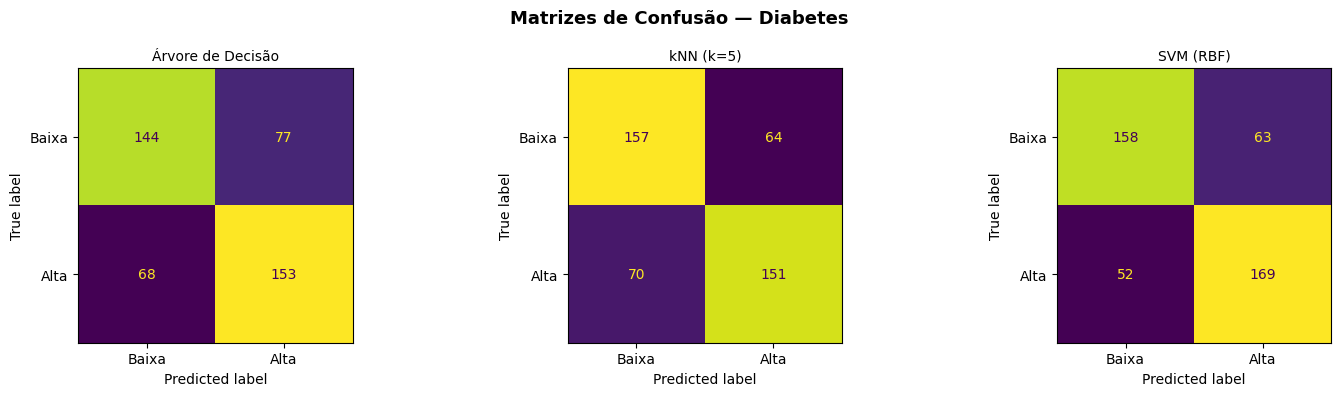


Métricas de avaliação (10-fold cross-validation):


,Classificador,Acurácia,Precision,Recall,F1-score
0,Árvore de Decisão,0.6719,0.6652,0.6923,0.6785
1,kNN (k=5),0.6968,0.7023,0.6833,0.6927
2,SVM (RBF),0.7398,0.7284,0.7647,0.7461



→ Melhor classificador: SVM (RBF) (Acurácia = 0.7398)


In [10]:
# Carregar e preparar o dataset Diabetes
diabetes_raw = load_diabetes()
X_diab = diabetes_raw.data
y_diab = (diabetes_raw.target > np.median(diabetes_raw.target)).astype(int)

print(f'Dataset Diabetes: {X_diab.shape[0]} instâncias, {X_diab.shape[1]} características')
print(f'Características: {diabetes_raw.feature_names}')
print(f'Mediana da progressão da doença: {np.median(diabetes_raw.target):.1f}')
print(f'Classe 0 (progressão ≤ mediana): {(y_diab == 0).sum()} instâncias')
print(f'Classe 1 (progressão > mediana): {(y_diab == 1).sum()} instâncias')

resultados_diabetes = avaliar_classificadores(
    X_diab, y_diab, 'Diabetes', classes=['Baixa', 'Alta']
)

---

### 3(c) Três conjuntos de dados adicionais

Os três conjuntos de dados escolhidos para repetir a análise são:

| # | Dataset | Instâncias | Características | Classes |
|---|---------|-----------|----------------|----------|
| 1 | **Iris** | 150 | 4 | 3 (setosa, versicolor, virginica) |
| 2 | **Wine** | 178 | 13 | 3 (class_0, class_1, class_2) |
| 3 | **Breast Cancer** | 569 | 30 | 2 (malignant, benign) |

#### Dataset adicional 1 — Iris


  Dataset: Iris  |  Instâncias: 150  |  Características: 4


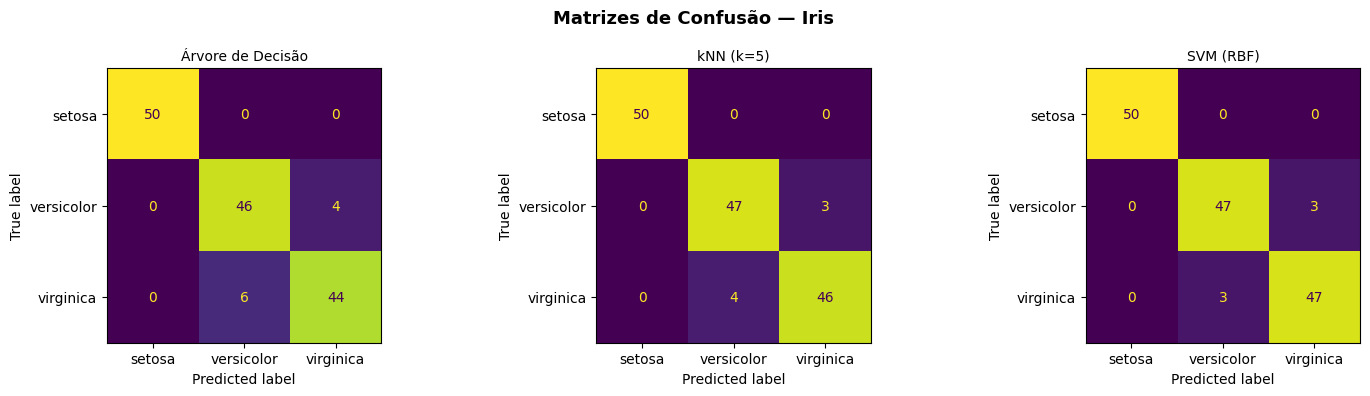


Métricas de avaliação (10-fold cross-validation):


,Classificador,Acurácia,Precision,Recall,F1-score
0,Árvore de Decisão,0.9333,0.9338,0.9333,0.9333
1,kNN (k=5),0.9533,0.9534,0.9533,0.9533
2,SVM (RBF),0.9600,0.9600,0.9600,0.9600



→ Melhor classificador: SVM (RBF) (Acurácia = 0.9600)


In [11]:
iris_data = load_iris()
resultados_iris = avaliar_classificadores(
    iris_data.data, iris_data.target,
    'Iris', classes=iris_data.target_names
)

#### Dataset adicional 2 — Wine


  Dataset: Wine  |  Instâncias: 178  |  Características: 13


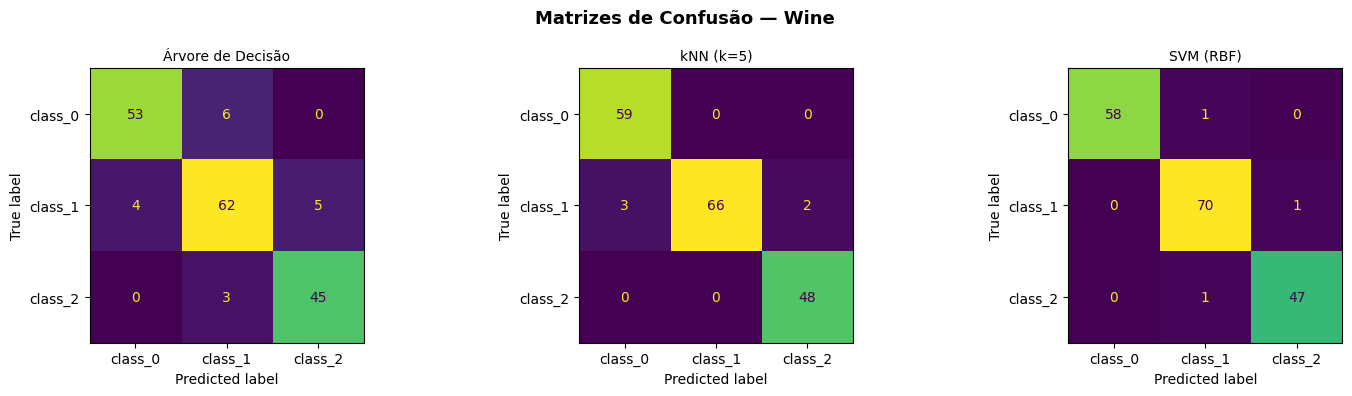


Métricas de avaliação (10-fold cross-validation):


,Classificador,Acurácia,Precision,Recall,F1-score
0,Árvore de Decisão,0.8989,0.8992,0.8989,0.8989
1,kNN (k=5),0.9719,0.9732,0.9719,0.9717
2,SVM (RBF),0.9831,0.9833,0.9831,0.9832



→ Melhor classificador: SVM (RBF) (Acurácia = 0.9831)


In [12]:
wine_data = load_wine()
resultados_wine = avaliar_classificadores(
    wine_data.data, wine_data.target,
    'Wine', classes=wine_data.target_names
)

#### Dataset adicional 3 — Breast Cancer


  Dataset: Breast Cancer  |  Instâncias: 569  |  Características: 30


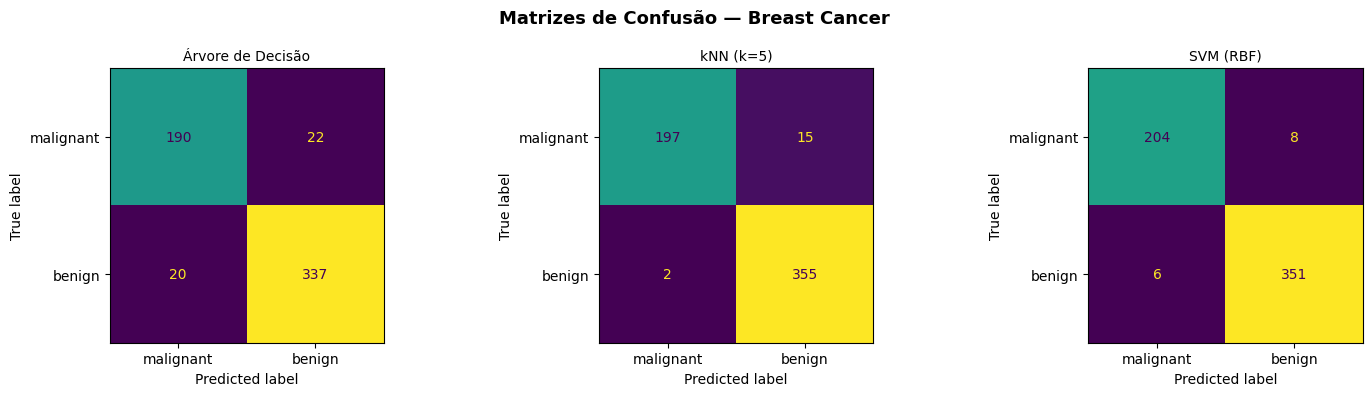


Métricas de avaliação (10-fold cross-validation):


,Classificador,Acurácia,Precision,Recall,F1-score
0,Árvore de Decisão,0.9262,0.9387,0.9440,0.9413
1,kNN (k=5),0.9701,0.9595,0.9944,0.9766
2,SVM (RBF),0.9754,0.9777,0.9832,0.9804



→ Melhor classificador: SVM (RBF) (Acurácia = 0.9754)


In [13]:
bc_data = load_breast_cancer()
resultados_bc = avaliar_classificadores(
    bc_data.data, bc_data.target,
    'Breast Cancer', classes=bc_data.target_names
)

---

### Resumo comparativo dos classificadores

In [14]:
todos_resultados = {
    'Diabetes':      resultados_diabetes,
    'Iris':          resultados_iris,
    'Wine':          resultados_wine,
    'Breast Cancer': resultados_bc,
}

linhas = []
for dataset, resultados in todos_resultados.items():
    for clf, metricas in resultados.items():
        linhas.append({
            'Dataset': dataset,
            'Classificador': clf,
            'Acurácia': f"{metricas['accuracy']:.4f}",
            'Precision': f"{metricas['precision']:.4f}",
            'Recall': f"{metricas['recall']:.4f}",
            'F1-score': f"{metricas['f1']:.4f}",
        })

df_resumo = pd.DataFrame(linhas)
print('Resumo comparativo — todos os datasets e classificadores:')
display(df_resumo)

# Melhor classificador por dataset
print('\nMelhor classificador por dataset (maior acurácia):')
for dataset, resultados in todos_resultados.items():
    melhor = max(resultados, key=lambda k: resultados[k]['accuracy'])
    acc = resultados[melhor]['accuracy']
    print(f'  {dataset:<15} → {melhor:<20} (Acurácia = {acc:.4f})')

Resumo comparativo — todos os datasets e classificadores:


,Dataset,Classificador,Acurácia,Precision,Recall,F1-score
0,Diabetes,Árvore de Decisão,0.6719,0.6652,0.6923,0.6785
1,Diabetes,kNN (k=5),0.6968,0.7023,0.6833,0.6927
2,Diabetes,SVM (RBF),0.7398,0.7284,0.7647,0.7461
3,Iris,Árvore de Decisão,0.9333,0.9338,0.9333,0.9333
4,Iris,kNN (k=5),0.9533,0.9534,0.9533,0.9533
5,Iris,SVM (RBF),0.9600,0.9600,0.9600,0.9600
6,Wine,Árvore de Decisão,0.8989,0.8992,0.8989,0.8989
7,Wine,kNN (k=5),0.9719,0.9732,0.9719,0.9717
8,Wine,SVM (RBF),0.9831,0.9833,0.9831,0.9832
9,Breast Cancer,Árvore de Decisão,0.9262,0.9387,0.9440,0.9413



Melhor classificador por dataset (maior acurácia):
  Diabetes        → SVM (RBF)            (Acurácia = 0.7398)
  Iris            → SVM (RBF)            (Acurácia = 0.9600)
  Wine            → SVM (RBF)            (Acurácia = 0.9831)
  Breast Cancer   → SVM (RBF)            (Acurácia = 0.9754)


---

## Conclusões

### Análise de dados (Secção 2)

- O dataset **Iris** é simples, completamente numérico e sem valores omissos — ideal para introdução à aprendizagem automática.
- O dataset **Penguins** apresenta uma mistura de características numéricas e categóricas, com uma pequena percentagem de valores omissos (~0.92%), tornando-o mais próximo de um cenário real.
- O dataset **Titanic** tem uma percentagem relevante de valores omissos (especialmente na coluna *age*) e características de tipos distintos, o que exige pré-processamento antes de treinar modelos.

### Classificação (Secção 3)

- O **SVM** com kernel RBF foi consistentemente o melhor ou um dos melhores classificadores em todos os datasets testados, beneficiando da normalização das características.
- O **kNN** apresentou bons resultados em datasets com classes bem separadas (Wine, Breast Cancer), mas é mais sensível a características irrelevantes e à escala dos dados.
- A **Árvore de Decisão** é o classificador mais interpretável, mas tende a sobreajustar em datasets com muitas características, o que se reflete numa acurácia geralmente inferior.
- Em todos os datasets, o uso de 10-fold cross-validation garantiu uma estimativa robusta do desempenho dos modelos, minimizando a variância das métricas.